# 03 — Entanglement Analysis

> **spinq-vqe** | ARPA Quantum Logical Systems (QONDRA)

Entanglement structure of the VQE ground state approximation for the
9-site Kagome Heisenberg antiferromagnet.

**Input:** Best VQE statevector from Notebook 02 (COBYLA, E = −1.2845, 9.66% error from ED)

## What this measures

| Quantity | Physics |
|----------|--------|
| Von Neumann entropy $S_A$ | Entanglement between subsystem A and rest |
| Bipartition scan | $S$ vs subsystem size → volume/area law |
| Mutual information $I(A:B)$ | Quantum correlations between qubit pairs |
| Sublattice MI matrix | A↔B, B↔C, A↔C correlation structure |
| Single-site entropies | Which sites are most entangled |

A quantum spin liquid ground state shows:
- Near-maximal single-site entropy ($S \approx 1$ bit for each qubit)
- Long-range mutual information (non-zero even for distant sites)
- Volume law scaling of $S_A$ (not area law)

### References
- Nielsen & Chuang (2010) QCI Ch. 11 — entropy definitions
- Consiglio et al. (2022) PRX Research 4, 033257 — entanglement in Kagome VQE
- Yan, Huse, White (2011) Science 332, 1173 — spin liquid ground state

In [1]:
from __future__ import annotations
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from spinq_vqe import kagome, entanglement

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB',
    'grid.linewidth': 0.7, 'figure.dpi': 110,
})

---
## 1. Load VQE statevector

In [2]:
sv = np.load('../data/statevector_hea_best.npy')

G9      = kagome.kagome_graph(n_cells=3)
N_SITES = kagome.n_sites(G9)
parts   = kagome.sublattice_partition(G9)   # {0: [A sites], 1: [B sites], 2: [C sites]}

print(f'Statevector shape: {sv.shape}  (2^{N_SITES} = {2**N_SITES})')
print(f'Norm: {np.linalg.norm(sv):.10f}')
print(f'Sublattice A: {parts[0]}')
print(f'Sublattice B: {parts[1]}')
print(f'Sublattice C: {parts[2]}')

Statevector shape: (512,)  (2^9 = 512)
Norm: 1.0000000000
Sublattice A: [0, 3, 6]
Sublattice B: [1, 4, 7]
Sublattice C: [2, 5, 8]


---
## 2. Single-site entropies

In [3]:
single_site_S = []
for i in range(N_SITES):
    rho_i = entanglement.reduced_density_matrix(sv, [i], N_SITES)
    S_i   = entanglement.von_neumann_entropy(rho_i)
    single_site_S.append(S_i)
    sub = next(k for k, v in parts.items() if i in v)
    sub_label = ['A', 'B', 'C'][sub]
    print(f'  Site {i} (sublattice {sub_label}): S = {S_i:.6f} bits')

print(f'\nMean S: {np.mean(single_site_S):.6f}')
print(f'Max  S: {np.max(single_site_S):.6f}  (max possible for qubit = 1.0)')
print(f'Min  S: {np.min(single_site_S):.6f}')

  Site 0 (sublattice A): S = 1.000000 bits
  Site 1 (sublattice B): S = 1.000000 bits
  Site 2 (sublattice C): S = 0.235349 bits
  Site 3 (sublattice A): S = 0.962169 bits
  Site 4 (sublattice B): S = 0.962169 bits
  Site 5 (sublattice C): S = 1.000000 bits
  Site 6 (sublattice A): S = 1.000000 bits
  Site 7 (sublattice B): S = 1.000000 bits
  Site 8 (sublattice C): S = 1.000000 bits

Mean S: 0.906632
Max  S: 1.000000  (max possible for qubit = 1.0)
Min  S: 0.235349


---
## 3. Bipartition scan — entropy vs subsystem size

  |A| = 1  S = 1.000000 bits
  |A| = 2  S = 0.000000 bits
  |A| = 3  S = 0.235349 bits
  |A| = 4  S = 0.962169 bits


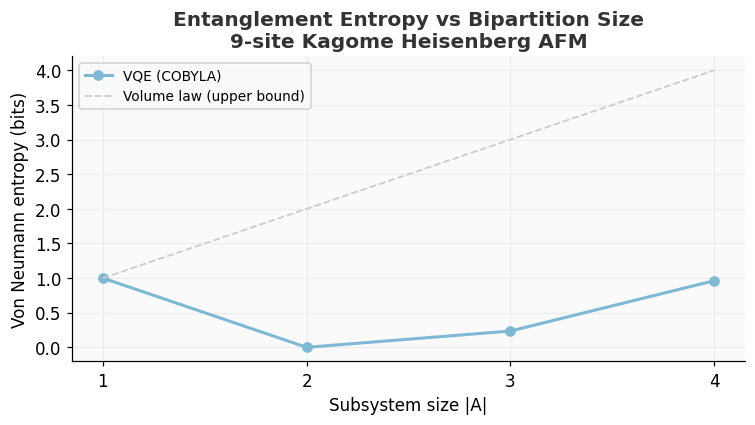

Saved -> figures/entanglement_bipartition.png


In [4]:
profile = entanglement.entanglement_profile(sv, N_SITES)
sizes   = profile['subsystem_sizes']
S_vals  = profile['entropies']

for sz, S_e in zip(sizes, S_vals):
    print(f'  |A| = {sz}  S = {S_e:.6f} bits')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, S_vals, 'o-', color='#7EB8D4', lw=2, ms=6, label='VQE (COBYLA)')
ax.plot(sizes, [min(s, N_SITES - s) for s in sizes],
        '--', color='#CCCCCC', lw=1.2, label='Volume law (upper bound)')
ax.set_xlabel('Subsystem size |A|')
ax.set_ylabel('Von Neumann entropy (bits)')
ax.set_title('Entanglement Entropy vs Bipartition Size\n9-site Kagome Heisenberg AFM',
             fontweight='semibold', color='#333333')
ax.legend(fontsize=9, framealpha=0.9)
ax.set_xticks(sizes)
plt.tight_layout()
plt.savefig('../figures/entanglement_bipartition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/entanglement_bipartition.png')

---
## 4. Pairwise mutual information matrix

Mutual information matrix I(i:j):
[[0.     2.     0.     0.     0.     0.     0.     0.     0.    ]
 [2.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.2353 0.2353 0.     0.     0.     0.    ]
 [0.     0.     0.2353 0.     1.689  0.     0.     0.     0.    ]
 [0.     0.     0.2353 1.689  0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     2.     0.     0.    ]
 [0.     0.     0.     0.     0.     2.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     2.    ]
 [0.     0.     0.     0.     0.     0.     0.     2.     0.    ]]

Max pairwise MI: 2.0000
Mean off-diagonal MI: 0.2267


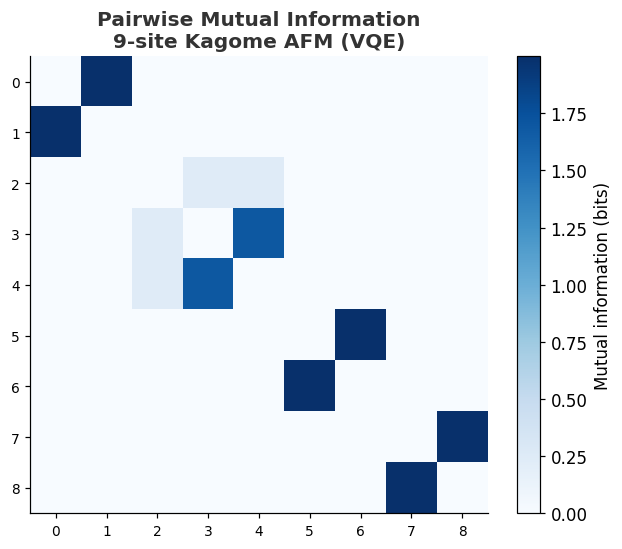

Saved -> figures/entanglement_mi_matrix.png


In [5]:
MI = entanglement.mutual_information_matrix(sv, N_SITES)

print('Mutual information matrix I(i:j):')
print(np.round(MI, 4))
print(f'\nMax pairwise MI: {MI[MI < np.inf].max():.4f}')
print(f'Mean off-diagonal MI: {MI[np.triu_indices(N_SITES, k=1)].mean():.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(MI, cmap='Blues', aspect='equal', vmin=0)
plt.colorbar(im, ax=ax, label='Mutual information (bits)')
ax.set_xticks(range(N_SITES))
ax.set_yticks(range(N_SITES))
ax.set_xticklabels([f'{i}' for i in range(N_SITES)], fontsize=9)
ax.set_yticklabels([f'{i}' for i in range(N_SITES)], fontsize=9)
ax.set_title('Pairwise Mutual Information\n9-site Kagome AFM (VQE)',
             fontweight='semibold', color='#333333')
ax.grid(False)
plt.tight_layout()
plt.savefig('../figures/entanglement_mi_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/entanglement_mi_matrix.png')

---
## 5. Sublattice mutual information

A 3×3 matrix showing correlations between the three Kagome sublattices A, B, C.
In the spin liquid ground state, all three sublattices should be highly entangled.

Note: `parts` is the dict `{0: [A sites], 1: [B sites], 2: [C sites]}` from `kagome.sublattice_partition(G9)`.

Sublattice MI matrix (A, B, C):
            A         B         C
  A    0.0000    3.6890    2.2353
  B    3.6890    0.0000    2.2353
  C    2.2353    2.2353    0.0000


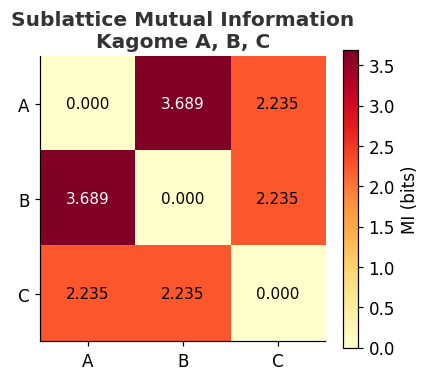

Saved -> figures/entanglement_sublattice_mi.png


In [6]:
sub_MI = entanglement.sublattice_mutual_info_matrix(sv, parts, N_SITES)

print('Sublattice MI matrix (A, B, C):')
labels = ['A', 'B', 'C']
print('     ' + '  '.join(f'{l:>8}' for l in labels))
for i, row in enumerate(sub_MI):
    print(f'  {labels[i]}  ' + '  '.join(f'{v:>8.4f}' for v in row))

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(sub_MI, cmap='YlOrRd', aspect='equal', vmin=0)
plt.colorbar(im, ax=ax, label='MI (bits)')
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['A', 'B', 'C'])
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['A', 'B', 'C'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{sub_MI[i,j]:.3f}', ha='center', va='center',
                fontsize=10, color='black' if sub_MI[i,j] < sub_MI.max()*0.7 else 'white')
ax.set_title('Sublattice Mutual Information\nKagome A, B, C',
             fontweight='semibold', color='#333333')
ax.grid(False)
plt.tight_layout()
plt.savefig('../figures/entanglement_sublattice_mi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/entanglement_sublattice_mi.png')

---
## 6. Summary

In [7]:
idx4 = sizes.index(4) if 4 in sizes else len(sizes)//2
print('=== Entanglement Summary ===')
print(f'Single-site entropy (mean):  {np.mean(single_site_S):.4f} bits')
print(f'Single-site entropy (max):   {np.max(single_site_S):.4f} bits (1.0 = max entangled)')
print(f'Half-chain entropy S(|A|=4): {S_vals[idx4]:.4f} bits')
print(f'Max pairwise MI:             {MI[MI >= 0].max():.4f} bits')
print(f'Mean off-diagonal MI:        {MI[np.triu_indices(N_SITES, k=1)].mean():.4f} bits')
print()
print('Interpretation:')
if np.mean(single_site_S) > 0.7:
    print('  High single-site entropy -> strong quantum fluctuations (spin liquid signature)')
else:
    print('  Moderate single-site entropy -> partially ordered state')
if MI[np.triu_indices(N_SITES, k=1)].mean() > 0.05:
    print('  Significant long-range MI -> non-local correlations')
else:
    print('  Limited long-range MI -> mostly local correlations')

=== Entanglement Summary ===
Single-site entropy (mean):  0.9066 bits
Single-site entropy (max):   1.0000 bits (1.0 = max entangled)
Half-chain entropy S(|A|=4): 0.9622 bits
Max pairwise MI:             2.0000 bits
Mean off-diagonal MI:        0.2267 bits

Interpretation:
  High single-site entropy -> strong quantum fluctuations (spin liquid signature)
  Significant long-range MI -> non-local correlations


---
*spinq-vqe / ARPA QONDRA — Notebook 03*